# Notebook 1 – Exploração de Embeddings e Drift

## Aula 5: Drift em Embeddings e Testes de Duas Amostras

### Objetivos
- Compreender o que são **embeddings** e como representam dados não estruturados
- Explorar o dataset sintético que simula o caso **TrendCast** (drift em redes sociais)
- Diferenciar **drift superficial** vs **drift semântico** (Feldhans et al., 2021)
- Visualizar distribuições de embeddings com **UMAP** e **t-SNE**

### Contexto Teórico (Documento da Aula 5)
> *"Os embeddings cumprem exatamente esse papel: são vetores densos de alta dimensionalidade em que cada palavra, frase ou documento é mapeado para um ponto em um espaço vetorial contínuo"* (Mikolov et al., 2013).

> *"Chamamos de drift superficial as alterações visíveis nos dados que não modificam fundamentalmente seu significado. Já o drift semântico envolve alterações de sentido ou contexto subjacente nos dados."*

**Vídeos relacionados:** Vídeo 1 (Embeddings e drift) e Vídeo 2 (Drift semântico e visualização)

In [9]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Adiciona o diretório pai ao path para importar src/
sys.path.insert(0, str(Path('..').resolve()))

from src.utils import set_seed, generate_synthetic_dataset
from src.data_preprocessing import DataPreprocessor

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
set_seed(42)

print('Imports carregados com sucesso!')

Imports carregados com sucesso!


## 1. Geração e Carregamento do Dataset

O dataset simula o cenário descrito na seção *'O que vem por aí'* do documento da Aula 5:
um sistema de ML que monitora tópicos de redes sociais e enfrenta mudanças na distribuição
quando eventos mundiais alteram os padrões de postagens.

Conforme o documento: *"Os posts sobre política disparam repentinamente e dominam as
discussões online, enquanto outros assuntos ficam em segundo plano."*

In [10]:
# Gera dataset sintético se não existir
dataset_path = Path('..') / 'data' / 'raw' / 'dataset.csv'

if not dataset_path.exists():
    print('Gerando dataset sintético...')
    df = generate_synthetic_dataset(output_path=str(dataset_path))
    print(f'Dataset gerado: {len(df)} amostras')
else:
    print('Dataset já existe, carregando...')

# Carrega com o DataPreprocessor
preprocessor = DataPreprocessor(embedding_dim=64)
df = preprocessor.load_data(str(dataset_path))

print(f'\nShape: {df.shape}')
print(f'Colunas: {list(df.columns[:6])}... + {preprocessor.embedding_dim} colunas de embedding')
df.head()

Dataset já existe, carregando...

Shape: (10000, 68)
Colunas: ['sample_id', 'period', 'category', 'timestamp', 'emb_0', 'emb_1']... + 64 colunas de embedding


,sample_id,period,category,timestamp,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,0,reference,esportes,2024-01-06,0.301484,0.256849,-0.124314,1.907563,-0.668095,-0.782107,...,1.694846,0.045346,0.058181,-0.054186,1.365036,0.045049,-0.699522,-0.421130,-1.716473,-0.886071
1,1,reference,esportes,2024-01-13,-0.167437,0.013242,0.511032,1.789136,0.403492,-0.433052,...,-0.417481,0.435215,-0.209247,-0.172514,-0.966753,0.438960,-0.954074,0.273965,-0.352373,-1.112897
2,2,reference,esportes,2024-01-22,-0.033099,-0.649287,0.289514,1.284668,-0.656981,0.159009,...,-0.250527,0.773991,-0.775980,-0.421416,-0.158836,0.014545,-0.213011,-0.547960,-0.405032,-0.625620
3,3,reference,esportes,2024-01-07,0.117480,-0.566225,0.007934,1.175260,0.157287,-0.652498,...,-0.600827,-0.086512,-1.444284,-0.347138,0.175720,1.405995,-0.060522,-0.212836,-0.098883,-1.809192
4,4,reference,esportes,2024-01-19,0.377408,0.353088,-0.486011,1.387975,0.068325,-0.344531,...,-0.411501,1.303409,-0.506153,-0.388419,-0.388721,-0.418630,0.211282,-0.052672,-1.259708,-1.307447


## 2. Análise Exploratória dos Períodos

Conforme discutido no documento da Aula 5, o drift pode se manifestar como:
- **Drift nas características** ($P(X)$): a distribuição das variáveis de entrada muda
- **Drift no conceito** ($P(y|X)$): a relação entrada-saída muda
- **Drift na proporção** ($P(y)$): a distribuição das classes se altera

In [11]:
# Distribuição por período
print('=== Distribuição por Período ===')
print(df['period'].value_counts())
print()

# Distribuição de categorias por período
print('=== Categorias por Período ===')
cat_by_period = pd.crosstab(df['period'], df['category'], normalize='index') * 100
print(cat_by_period.round(1))

=== Distribuição por Período ===
period
reference            5000
production_stable    2500
production_drift     2500
Name: count, dtype: int64

=== Categorias por Período ===
category           clima  entretenimento  esportes  politica  tecnologia
period                                                                  
production_drift    10.0            10.0      10.0      50.0        20.0
production_stable   20.0            20.0      20.0      20.0        20.0
reference           20.0            20.0      20.0      20.0        20.0


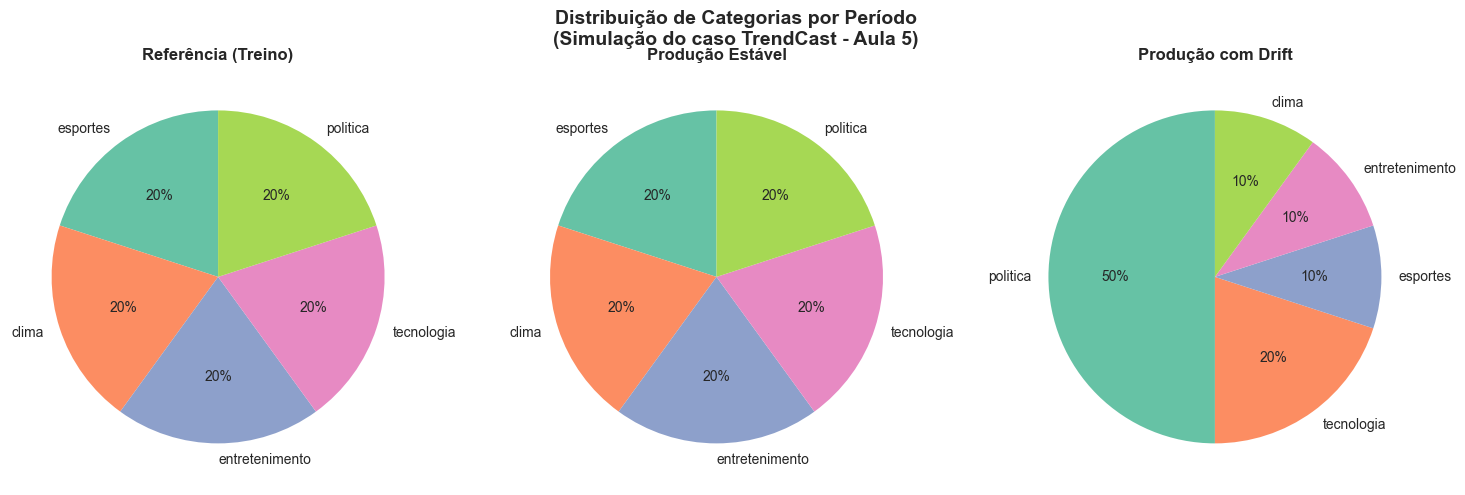

Observe como "política" domina no período com drift (50%), simulando um evento mundial que altera a distribuição de tópicos.


In [12]:
# Visualização das proporções de categorias por período
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

periods = ['reference', 'production_stable', 'production_drift']
titles = ['Referência (Treino)', 'Produção Estável', 'Produção com Drift']

for ax, period, title in zip(axes, periods, titles):
    data = df[df['period'] == period]['category'].value_counts()
    ax.pie(data, labels=data.index, autopct='%1.0f%%', startangle=90)
    ax.set_title(title, fontsize=12, fontweight='bold')

fig.suptitle('Distribuição de Categorias por Período\n'
             '(Simulação do caso TrendCast - Aula 5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/categorias_por_periodo.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observe como "política" domina no período com drift (50%), simulando '
      'um evento mundial que altera a distribuição de tópicos.')

## 3. Análise dos Embeddings

Conforme a seção *'Saiba Mais'* da Aula 5:

> *"Nos embeddings, a proximidade geométrica reflete semelhanças semânticas: palavras
> com significado relacionado tendem a ficar próximas"* (Mikolov et al., 2013; Devlin et al., 2019).

Vamos analisar as estatísticas dos embeddings para cada período.

In [13]:
# Limpeza dos dados
df_clean = preprocessor.clean_data()
print(f'Dados após limpeza: {len(df_clean)} amostras')

# Separar embeddings por período
emb_cols = preprocessor.embedding_cols

emb_ref = df_clean[df_clean['period'] == 'reference'][emb_cols].values
emb_stable = df_clean[df_clean['period'] == 'production_stable'][emb_cols].values
emb_drift = df_clean[df_clean['period'] == 'production_drift'][emb_cols].values

print(f'\nEmbeddings de referência: {emb_ref.shape}')
print(f'Embeddings produção estável: {emb_stable.shape}')
print(f'Embeddings produção com drift: {emb_drift.shape}')

Dados após limpeza: 10000 amostras

Embeddings de referência: (5000, 64)
Embeddings produção estável: (2500, 64)
Embeddings produção com drift: (2500, 64)


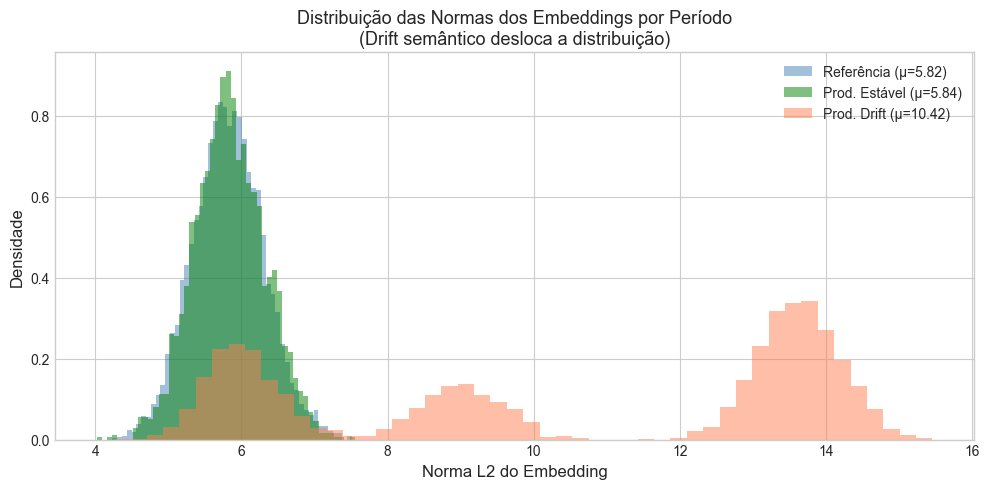

In [14]:
# Distribuição das normas dos embeddings por período
# A norma do vetor indica a "magnitude" da representação semântica
norms_ref = np.linalg.norm(emb_ref, axis=1)
norms_stable = np.linalg.norm(emb_stable, axis=1)
norms_drift = np.linalg.norm(emb_drift, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(norms_ref, bins=50, alpha=0.5, label=f'Referência (μ={norms_ref.mean():.2f})',
        color='steelblue', density=True)
ax.hist(norms_stable, bins=50, alpha=0.5, label=f'Prod. Estável (μ={norms_stable.mean():.2f})',
        color='green', density=True)
ax.hist(norms_drift, bins=50, alpha=0.5, label=f'Prod. Drift (μ={norms_drift.mean():.2f})',
        color='coral', density=True)

ax.set_xlabel('Norma L2 do Embedding', fontsize=12)
ax.set_ylabel('Densidade', fontsize=12)
ax.set_title('Distribuição das Normas dos Embeddings por Período\n'
             '(Drift semântico desloca a distribuição)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/normas_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

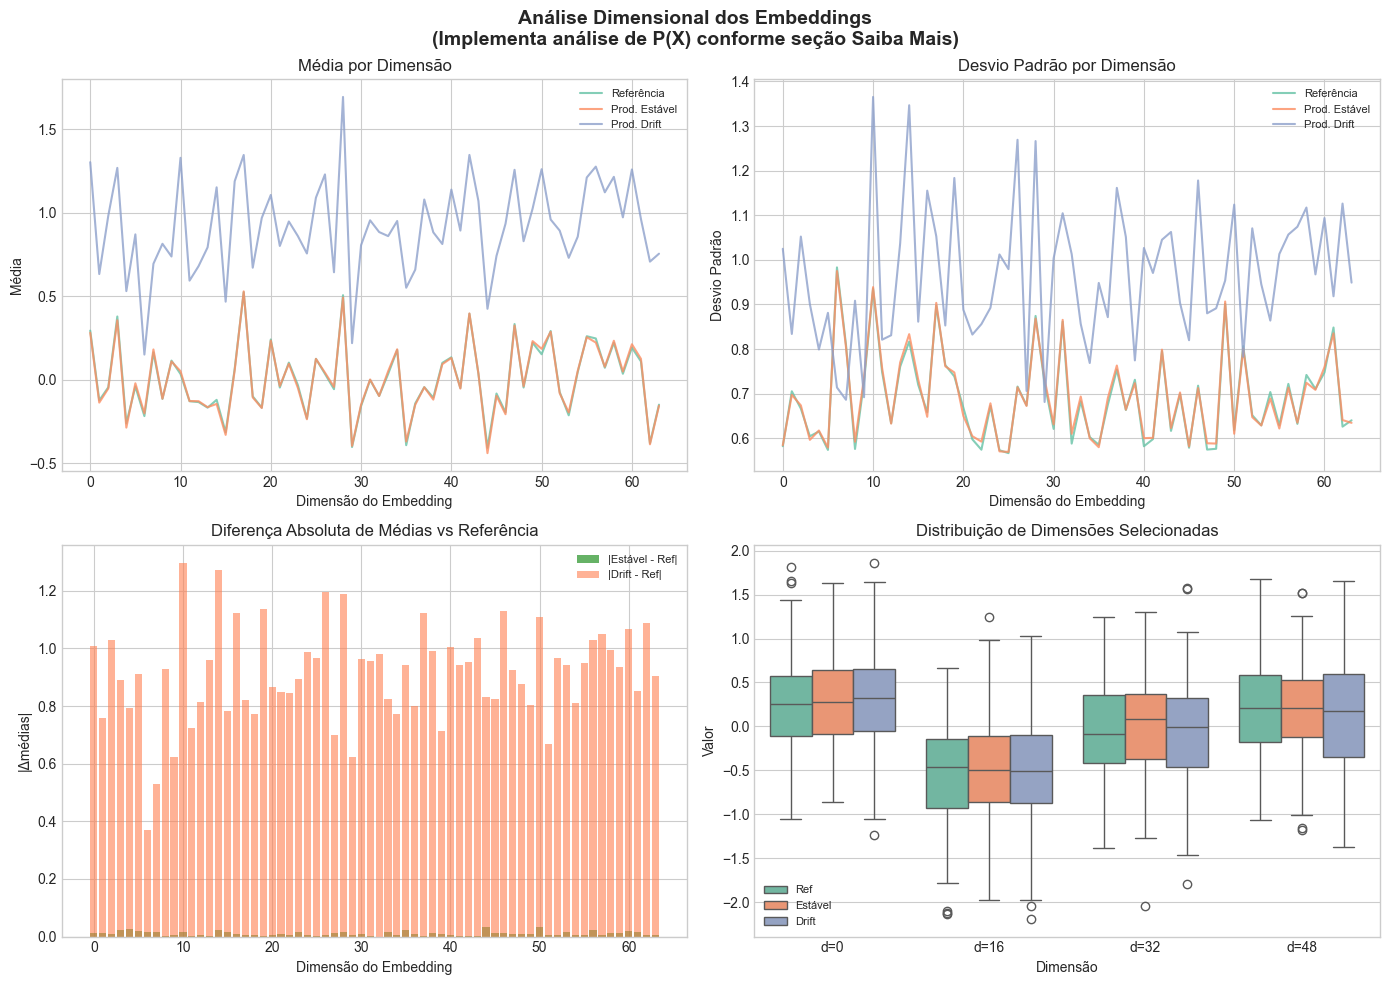

In [15]:
# Estatísticas por dimensão dos embeddings
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Média por dimensão
ax = axes[0, 0]
ax.plot(emb_ref.mean(axis=0), label='Referência', alpha=0.8)
ax.plot(emb_stable.mean(axis=0), label='Prod. Estável', alpha=0.8)
ax.plot(emb_drift.mean(axis=0), label='Prod. Drift', alpha=0.8)
ax.set_xlabel('Dimensão do Embedding')
ax.set_ylabel('Média')
ax.set_title('Média por Dimensão')
ax.legend(fontsize=8)

# Desvio padrão por dimensão
ax = axes[0, 1]
ax.plot(emb_ref.std(axis=0), label='Referência', alpha=0.8)
ax.plot(emb_stable.std(axis=0), label='Prod. Estável', alpha=0.8)
ax.plot(emb_drift.std(axis=0), label='Prod. Drift', alpha=0.8)
ax.set_xlabel('Dimensão do Embedding')
ax.set_ylabel('Desvio Padrão')
ax.set_title('Desvio Padrão por Dimensão')
ax.legend(fontsize=8)

# Diferença de médias: Drift vs Referência
ax = axes[1, 0]
diff_stable = np.abs(emb_stable.mean(axis=0) - emb_ref.mean(axis=0))
diff_drift = np.abs(emb_drift.mean(axis=0) - emb_ref.mean(axis=0))
ax.bar(range(64), diff_stable, alpha=0.6, label='|Estável - Ref|', color='green')
ax.bar(range(64), diff_drift, alpha=0.6, label='|Drift - Ref|', color='coral')
ax.set_xlabel('Dimensão do Embedding')
ax.set_ylabel('|Δmédias|')
ax.set_title('Diferença Absoluta de Médias vs Referência')
ax.legend(fontsize=8)

# Boxplot de algumas dimensões selecionadas
ax = axes[1, 1]
dims_to_show = [0, 16, 32, 48]
data_for_box = []
for dim in dims_to_show:
    for period, embs, name in [('Ref', emb_ref, 'Referência'),
                                ('Estável', emb_stable, 'Estável'),
                                ('Drift', emb_drift, 'Drift')]:
        for val in embs[:200, dim]:
            data_for_box.append({'Dimensão': f'd={dim}', 'Período': period, 'Valor': val})

df_box = pd.DataFrame(data_for_box)
sns.boxplot(data=df_box, x='Dimensão', y='Valor', hue='Período', ax=ax)
ax.set_title('Distribuição de Dimensões Selecionadas')
ax.legend(fontsize=8)

fig.suptitle('Análise Dimensional dos Embeddings\n'
             '(Implementa análise de P(X) conforme seção Saiba Mais)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/analise_dimensional.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Visualização com Redução de Dimensionalidade

Conforme discutido no Vídeo 2 da Aula 5, técnicas como **t-SNE** e **UMAP** permitem
projetar embeddings de alta dimensionalidade em 2D para visualização.

Isso permite identificar visualmente se os clusters de referência e produção
se sobrepõem (sem drift) ou se separam (drift detectado).

In [20]:
from sklearn.manifold import TSNE

# Subsample para visualização mais rápida
n_vis = 500
idx_ref = np.random.choice(len(emb_ref), n_vis, replace=False)
idx_stable = np.random.choice(len(emb_stable), n_vis, replace=False)
idx_drift = np.random.choice(len(emb_drift), n_vis, replace=False)

combined_vis = np.vstack([emb_ref[idx_ref], emb_stable[idx_stable], emb_drift[idx_drift]])
labels_vis = (['Referência'] * n_vis + ['Prod. Estável'] * n_vis + ['Prod. Drift'] * n_vis)

# t-SNE: projeção 2D
print('Calculando t-SNE (pode levar alguns segundos)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
projected_tsne = tsne.fit_transform(combined_vis)

# Categorias para coloração
cats_ref = df_clean[df_clean['period'] == 'reference']['category'].values[idx_ref]
cats_stable = df_clean[df_clean['period'] == 'production_stable']['category'].values[idx_stable]
cats_drift = df_clean[df_clean['period'] == 'production_drift']['category'].values[idx_drift]
cats_all = np.concatenate([cats_ref, cats_stable, cats_drift])

print('t-SNE concluído!')

Calculando t-SNE (pode levar alguns segundos)...
t-SNE concluído!


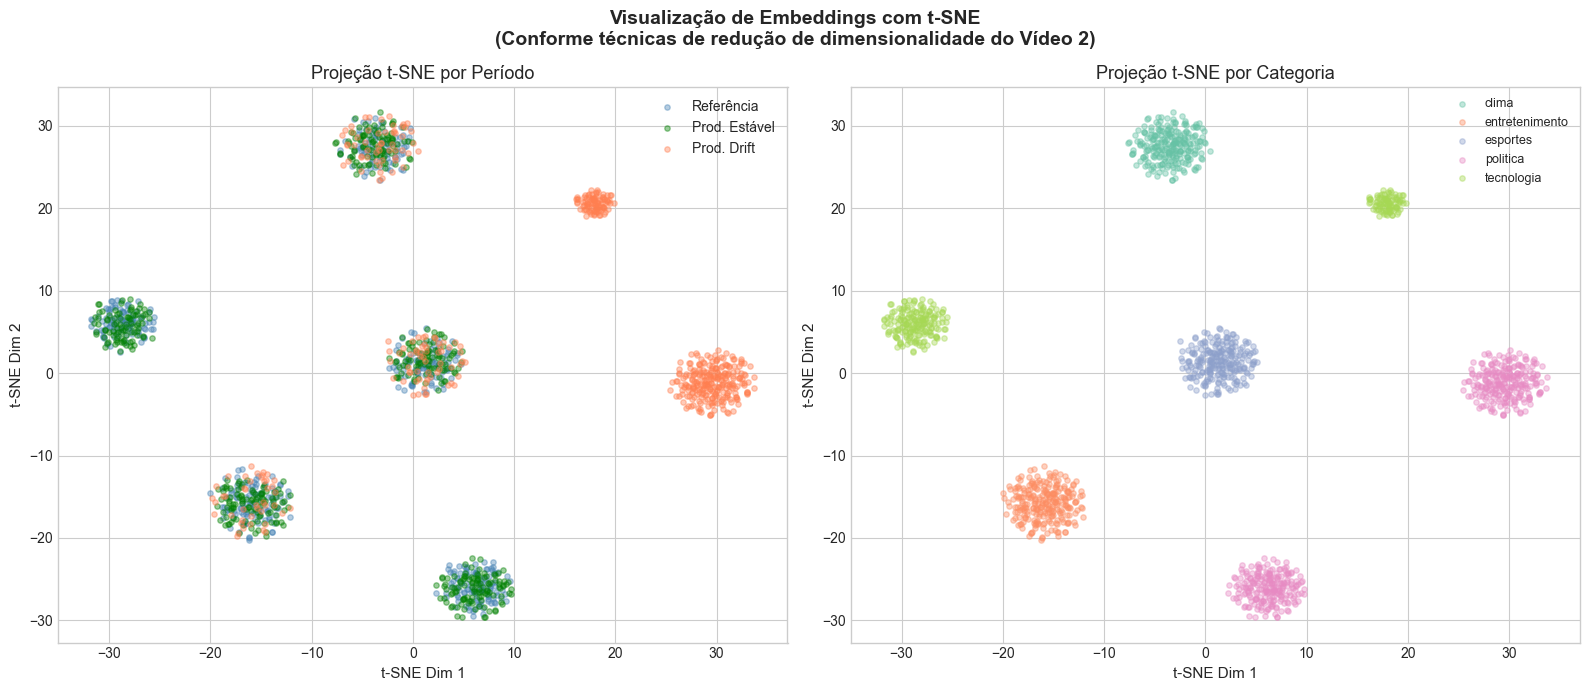

In [21]:
# Visualização t-SNE: Período
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Por período
ax = axes[0]
colors_period = {'Referência': 'steelblue', 'Prod. Estável': 'green', 'Prod. Drift': 'coral'}
for label in ['Referência', 'Prod. Estável', 'Prod. Drift']:
    mask = np.array(labels_vis) == label
    ax.scatter(projected_tsne[mask, 0], projected_tsne[mask, 1],
               alpha=0.4, s=15, label=label, c=colors_period[label])
ax.set_xlabel('t-SNE Dim 1', fontsize=11)
ax.set_ylabel('t-SNE Dim 2', fontsize=11)
ax.set_title('Projeção t-SNE por Período', fontsize=13)
ax.legend(fontsize=10)

# Por categoria
ax = axes[1]
unique_cats = np.unique(cats_all)
palette = sns.color_palette('Set2', len(unique_cats))
for i, cat in enumerate(unique_cats):
    mask = cats_all == cat
    ax.scatter(projected_tsne[mask, 0], projected_tsne[mask, 1],
               alpha=0.4, s=15, label=cat, c=[palette[i]])
ax.set_xlabel('t-SNE Dim 1', fontsize=11)
ax.set_ylabel('t-SNE Dim 2', fontsize=11)
ax.set_title('Projeção t-SNE por Categoria', fontsize=13)
ax.legend(fontsize=9)

fig.suptitle('Visualização de Embeddings com t-SNE\n'
             '(Conforme técnicas de redução de dimensionalidade do Vídeo 2)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Visualização com UMAP (se disponível)
try:
    import umap

    print('Calculando UMAP...')
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
    projected_umap = reducer.fit_transform(combined_vis)

    fig, ax = plt.subplots(figsize=(10, 7))
    for label in ['Referência', 'Prod. Estável', 'Prod. Drift']:
        mask = np.array(labels_vis) == label
        ax.scatter(projected_umap[mask, 0], projected_umap[mask, 1],
                   alpha=0.4, s=15, label=label, c=colors_period[label])

    ax.set_xlabel('UMAP Dim 1', fontsize=11)
    ax.set_ylabel('UMAP Dim 2', fontsize=11)
    ax.set_title('Projeção UMAP dos Embeddings por Período\n'
                 '(Método de visualização discutido no Vídeo 2 da Aula 5)',
                 fontsize=13)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('../outputs/figures/umap_embeddings.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('UMAP concluído!')

except ImportError:
    print('UMAP não instalado. Instale com: pip install umap-learn')
    print('A visualização t-SNE acima já demonstra o conceito.')

UMAP não instalado. Instale com: pip install umap-learn
A visualização t-SNE acima já demonstra o conceito.


## 5. Análise de Similaridade entre Períodos

Conforme a seção *'Saiba Mais'* da Aula 5:

> *"Ao acompanhar a evolução dos embeddings, podemos quantificar matematicamente se
> o 'espaço semântico' dos dados está se deslocando."*

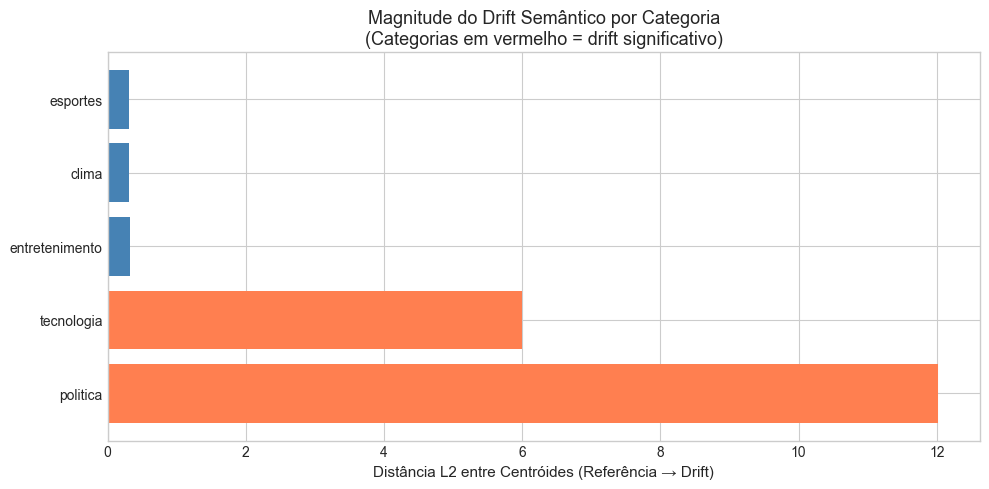


Distâncias entre centróides (Referência → Produção com Drift):
     Categoria  Distância L2
      politica     12.025623
    tecnologia      6.002830
entretenimento      0.321809
         clima      0.314303
      esportes      0.302610

As categorias "política" e "tecnologia" apresentam maior drift,
simulando o cenário descrito no documento da Aula 5.


In [23]:
# Distâncias entre centróides por categoria e período
categories = df_clean['category'].unique()

centroid_distances = []
for cat in categories:
    emb_ref_cat = df_clean[(df_clean['period'] == 'reference') &
                           (df_clean['category'] == cat)][emb_cols].values
    emb_drift_cat = df_clean[(df_clean['period'] == 'production_drift') &
                              (df_clean['category'] == cat)][emb_cols].values
    if len(emb_ref_cat) > 0 and len(emb_drift_cat) > 0:
        centroid_ref = emb_ref_cat.mean(axis=0)
        centroid_drift = emb_drift_cat.mean(axis=0)
        distance = np.linalg.norm(centroid_ref - centroid_drift)
        centroid_distances.append({'Categoria': cat, 'Distância L2': distance})

df_distances = pd.DataFrame(centroid_distances)
df_distances = df_distances.sort_values('Distância L2', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_distances['Categoria'], df_distances['Distância L2'],
               color=['coral' if d > 5 else 'steelblue'
                      for d in df_distances['Distância L2']])
ax.set_xlabel('Distância L2 entre Centróides (Referência → Drift)', fontsize=11)
ax.set_title('Magnitude do Drift Semântico por Categoria\n'
             '(Categorias em vermelho = drift significativo)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/drift_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDistâncias entre centróides (Referência → Produção com Drift):')
print(df_distances.to_string(index=False))
print('\nAs categorias "política" e "tecnologia" apresentam maior drift,')
print('simulando o cenário descrito no documento da Aula 5.')

## Resumo

Neste notebook, exploramos:

1. **Dataset sintético** que simula o caso TrendCast com 10.000 amostras e 3 períodos
2. **Drift de proporção**: a categoria "política" passa de 20% para 50% no período de drift
3. **Drift semântico**: as categorias "política" e "tecnologia" têm seus centróides deslocados
4. **Visualizações** com t-SNE e UMAP mostrando a separação entre períodos
5. **Análise de centróides** confirmando que o drift é mais forte em categorias específicas

### Próximo Notebook
No **Notebook 2 (Treinamento)**, aplicaremos os testes estatísticos de duas amostras
(MMD, KS) e o classificador adversário para detectar e quantificar o drift formalmente.

→ [02_treinamento.ipynb](02_treinamento.ipynb)